### Multiclass classification

When we have more than two classes as an option, it's known as **multi-class classification**.
* This means if you have 3 different classes, it'a multiclass classification.
* It alos means if we have 1000 different classes, that is also multiclass classification.

To practice multi-class classification , we're going to build a neural network to classify images of different itemns of clothing.

*we will use **Fashion MNIST** dataset*

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# The data has already been sorted into training and test sets for us
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

2026-05-22 13:52:36.829166: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Show the foirst training examples
print(f'Training sample:\n{train_data[0]}\n')
print(f'Training label:\n{train_labels[0]}\n')

Training sample:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1  

In [3]:
# check the shape of single examample
train_data[0].shape, train_labels[0].shape

((28, 28), ())

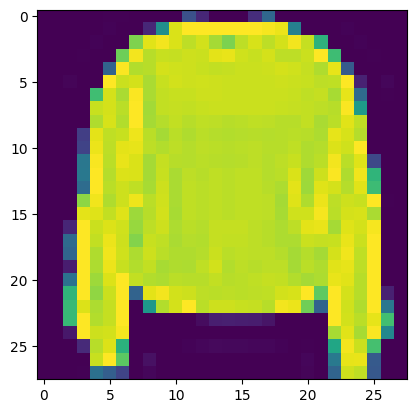

In [4]:
# plot a single sample
import matplotlib.pyplot as plt
plt.imshow(train_data[7])

In [5]:
# check out the smaple labels
train_labels[7]

2

In [6]:
# create a small list so we can index onto our training labels so they're human readable
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

len(class_names)

10

Text(0.5, 1.0, 'Ankle boot')

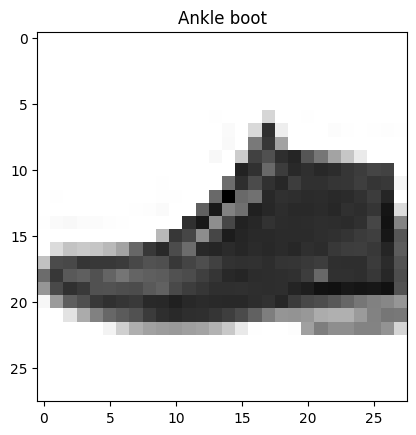

In [7]:
# plot an example image and its label
index_of_choice = 1232
plt.imshow(train_data[index_of_choice], cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

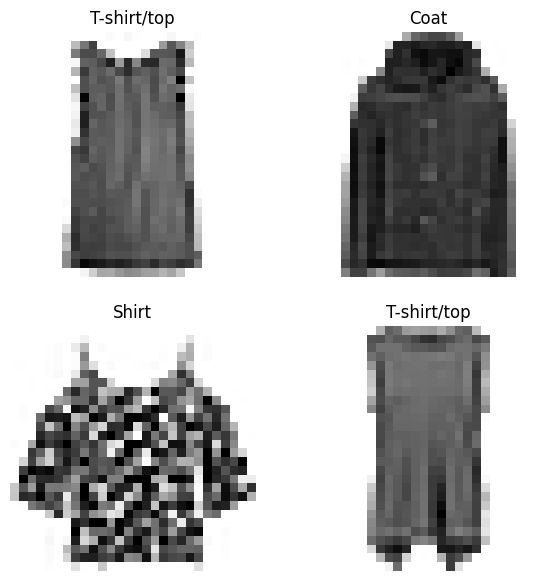

In [8]:
# plot multiple random image of fashion MNIST
# plot 4 random items
import random
plt.figure(figsize=(7,7))
for i in range(4):
    az = plt.subplot(2, 2, i+1)
    rand_index = random.choice(range(len(train_data)))
    plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
    plt.title(class_names[train_labels[rand_index]])
    plt.axis(False)

### let's build a multiclass classification model

For our multiclass classification model, we can use a similar architecture to our binary classifiers, however, we're going to tweak a few things:
* Input shape = (28, 28) the shape of one image
* Output shape = 10
* Loss function = tf.keras.losses.CategoricalCrossentropy()
  * If your labels are one-hot encoded, use CateegoricalCrossentropy()
  * If your labels are in integer form use SparseCateegoricalCrossentropy()
* Output activation = softmax (not sigmoid)

In [9]:
flatten_model = tf.keras.Sequential([tf.keras.layers.Flatten(input_shape=(28,28))])
flatten_model.output_shape

/Users/spy/Desktop/dl-journey/.venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


(None, 784)

In [10]:
28 * 28

784

In [11]:
# our data needs to be flattened from (28 * 28 to None, 784)
flattened_model = tf.keras.Sequential([tf.keras.layers.Flatten(input_shape=(28,28))])
flatten_model.output_shape

(None, 784)

In [12]:
tf.one_hot(train_labels[:10], depth=10)

<tf.Tensor: shape=(10, 10), dtype=float32, numpy=
array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)>

In [13]:
# set random seed
tf.random.set_seed(42)

# 1. create a model
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax)
])

# 2. compile the model
model.compile(loss=tf.keras.losses.CategoricalCrossentropy(),     # SparseCategoricalCrossentropy,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

# 3. fit the model
non_norm_history = model.fit(train_data,
                             tf.one_hot(train_labels, depth=10),
                             epochs=10,
                             validation_data=(test_data, tf.one_hot(test_labels, depth=10)))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0978 - loss: 2.3810 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.0973 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.0974 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0973 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.0973 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0973 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0973 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.0973 - loss: 2.3028 - 

In [14]:
# Check the model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

In [15]:
# check min and max of training data
train_data.min(), tf.math.reduce_max(train_data).numpy()

(0, 255)

Neural networtk prefer dqata to be scaled (or normalized) this means they like to have numbers in the tensors they try to find patterns between 0 and 1.

In [16]:
# we can get our training ans test data between 0 and 1 by dividing by the maximumn number
train_data_norm = train_data / 255.0
test_data_norm = test_data / 255.0

In [17]:
# check the min and max of scaled data
tf.math.reduce_min(train_data_norm).numpy(), tf.math.reduce_max(test_data_norm).numpy()

(0.0, 1.0)

In [18]:
# using ecxact same model with normalized data
# set random seed
tf.random.set_seed(42)

# 1. create a model
norm_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax)
])

# 2. compile the model
norm_model.compile(loss=tf.keras.losses.CategoricalCrossentropy(),     # SparseCategoricalCrossentropy,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

# 3. fit the model
norm_history = norm_model.fit(train_data_norm,
                             tf.one_hot(train_labels, depth=10),
                             epochs=10,
                             validation_data=(test_data_norm, tf.one_hot(test_labels, depth=10)))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5603 - loss: 1.2317 - val_accuracy: 0.7072 - val_loss: 0.8498
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7562 - loss: 0.7232 - val_accuracy: 0.7559 - val_loss: 0.7006
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7844 - loss: 0.6323 - val_accuracy: 0.7741 - val_loss: 0.6519
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7954 - loss: 0.5973 - val_accuracy: 0.7865 - val_loss: 0.6262
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8012 - loss: 0.5749 - val_accuracy: 0.7926 - val_loss: 0.6122
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8061 - loss: 0.5603 - val_accuracy: 0.7929 - val_loss: 0.6077
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8102 - loss: 0.5484 - val_accuracy: 0.8002 - val_loss: 0.5907
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8153 - loss: 0.5354 - 

🔑 **Note**: Neural Networks tend to ptrefer data in numerical form as well as scaled/normalized (numbers between 0 & 1).

### plotting the loss curves

<Axes: title={'center': 'Normalized data'}>

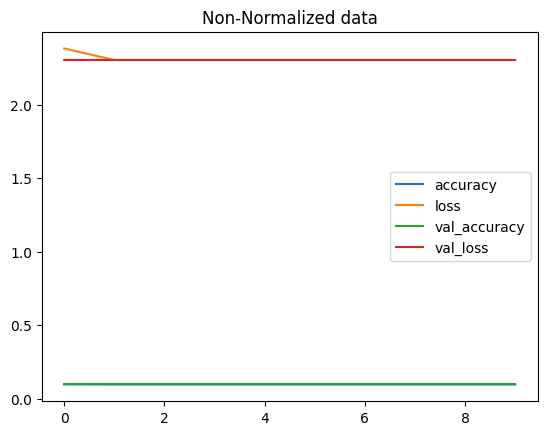

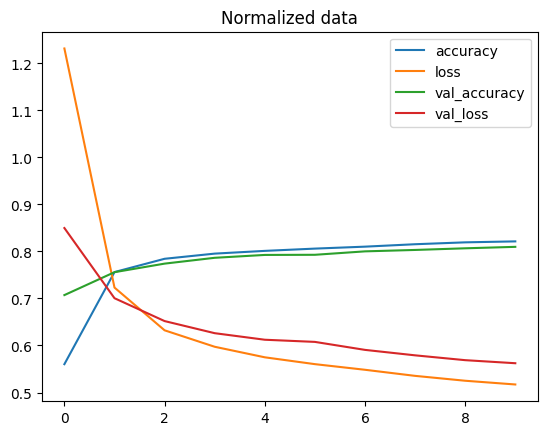

In [19]:
# loss curves of each model
import pandas as pd

# plot non-normalized data
pd.DataFrame(non_norm_history.history).plot(title='Non-Normalized data')
# plot normalized data
pd.DataFrame(norm_history.history).plot(title='Normalized data')

> 🔑 **Note**: The same model with even *slightly* differnet data can produce *dramatically* different results. so when you're comparing them on the same criteria (e.g. same architecture but different data or same data but different architecture).

### Findig the ideal learning rate

In [20]:
# set random seed
tf.random.set_seed(42)

# create a model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax)
])

# compile the model
model_1.compile(loss=tf.keras.losses.CategoricalCrossentropy(),     # SparseCategoricalCrossentropy,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

# create the learninf rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10 ** (epoch/20))

# fit the model
find_lr_history = model_1.fit(
                            train_data_norm,
                            tf.one_hot(train_labels, depth=10), # Clean integer labels
                            epochs=40,
                            validation_data=(test_data_norm, tf.one_hot(test_labels, depth=10)), # Clean integer labels
                            callbacks=[lr_scheduler])

/Users/spy/Desktop/dl-journey/.venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5282 - loss: 1.2003 - val_accuracy: 0.6850 - val_loss: 0.9212 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7204 - loss: 0.8113 - val_accuracy: 0.7492 - val_loss: 0.7443 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7563 - loss: 0.7107 - val_accuracy: 0.7620 - val_loss: 0.6934 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7821 - loss: 0.6276 - val_accuracy: 0.7876 - val_loss: 0.6124 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8017 - loss: 0.5825 - val_accuracy: 0.7989 - val_loss: 0.5891 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8083 - loss: 0.5606 - val_accuracy: 0.8020 - val_loss: 0.5786 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8113 - l

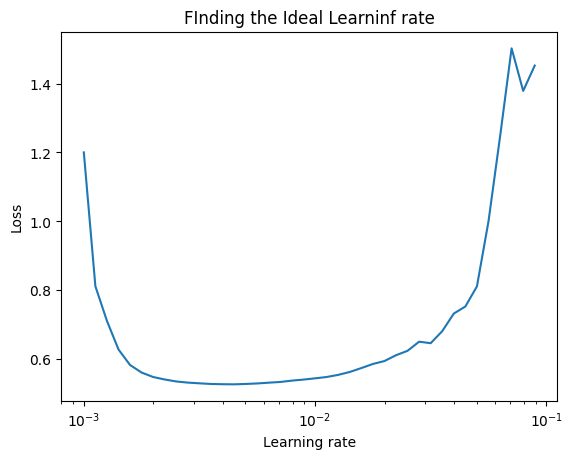

In [21]:
# plot learninf rate decay curves
import matplotlib.pyplot as plt

lrs = 1e-3 * (10 ** (tf.range(40)/20))
plt.semilogx(lrs, find_lr_history.history['loss'])
plt.xlabel('Learning rate')
plt.ylabel('Loss')
plt.title('FInding the Ideal Learninf rate')
plt.show()

In [23]:
# let refit the model with Ideal Learning rate

# set random seed
tf.random.set_seed(42)

# create a model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax)
])

# compile the model
model_2.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),     # SparseCategoricalCrossentropy,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

# create the learninf rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10 ** (epoch/20))

# fit the model
find_lr_history = model_2.fit(
                            train_data_norm,
                            train_labels, # Clean integer labels
                            epochs=20,
                            validation_data=(test_data_norm, test_labels), # Clean integer labels
)

/Users/spy/Desktop/dl-journey/.venv/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5671 - loss: 1.2132 - val_accuracy: 0.7128 - val_loss: 0.8707
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7224 - loss: 0.7911 - val_accuracy: 0.7341 - val_loss: 0.7694
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7401 - loss: 0.7319 - val_accuracy: 0.7427 - val_loss: 0.7334
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7486 - loss: 0.7028 - val_accuracy: 0.7456 - val_loss: 0.7130
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7528 - loss: 0.6847 - val_accuracy: 0.7500 - val_loss: 0.7000
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7563 - loss: 0.6726 - val_accuracy: 0.7530 - val_loss: 0.6909
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7596 - loss: 0.6631 - val_accuracy: 0.7550 - val_loss: 0.6842
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7624 - loss: 0.6552 - 

### Evaluating our multiclass classification model

To evaluate our multiclass classification model we could:
* Evaluate its performance using other classification metrics (such as confusion matrix).
*  Asees some of its predictions (through visualisation).
* Improve its results (by training for longer or changing its architecture).
* Save and export it for use in a application.

Let's go through the top 2...

In [40]:
import itertools
import numpy as np

figsize = (10, 10)

# create the confusion matrix
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10,10), text_size=15):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize our confusion matrix
    n_classes = cm.shape[0]

    # let's prettify it
    fig, ax = plt.subplots(figsize=figsize)
    # creat a matrix plot
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)

    # set labels to be classes
    if classes:
        labels = classes
    else:
        labels = np.arange(cm.shape[0])

    # labe; the axes
    ax.set(title="Confusion Matrix",
            xlabel="Predicted Label",
            ylabel="True Label",
            xticks=np.arange(n_classes),
            yticks=np.arange(n_classes),
            xticklabels=labels,
            yticklabels=labels)

    # set x axis label to bottom
    ax.xaxis.set_label_position('bottom')
    ax.xaxis.tick_bottom()

    # Adjust label size
    ax.yaxis.label.set_size(text_size)
    ax.xaxis.label.set_size(text_size)
    ax.title.set_size(text_size)


    # set threshold for different colors
    threshold = (cm.max() + cm.min()) / 2.

    # plot the text on each cell
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i, j]}  ({cm_norm[i,j]*100:.1f}%)",
                horizontalalignment='center',
                color="white" if cm[i, j] > threshold else "black",
                size=15)

In [41]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [42]:
# make some predictions with our models
y_probs  = model_2.predict(test_data_norm)  # probs is short for predictions probabilities

# view the first 5 predictions 
y_probs[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step


array([[1.7476331e-08, 1.9290630e-12, 1.9289468e-14, 5.3756349e-10,
        5.8358362e-12, 1.5970890e-01, 2.0496451e-09, 2.3658085e-01,
        1.1305193e-05, 6.0369885e-01],
       [5.4895255e-04, 3.0205966e-11, 4.4603109e-01, 1.5786324e-04,
        3.5018799e-01, 2.4162647e-17, 1.8923411e-01, 1.9394901e-07,
        1.3839903e-02, 1.6457149e-16],
       [3.3157244e-07, 9.9753940e-01, 6.5408013e-12, 1.9564156e-03,
        7.3105935e-09, 5.0373783e-04, 4.8415929e-09, 2.7760373e-13,
        1.9695823e-10, 8.6138158e-10],
       [3.2772618e-08, 9.9865109e-01, 2.5145744e-13, 1.3028312e-03,
        2.2735973e-09, 4.6128582e-05, 4.6853588e-10, 3.5431871e-15,
        2.1435622e-11, 5.0892245e-11],
       [1.8837860e-01, 1.4458779e-04, 3.0110252e-01, 4.0462438e-02,
        2.7509091e-02, 2.3486400e-06, 4.2474008e-01, 9.4037526e-04,
        1.6719908e-02, 2.5044738e-08]], dtype=float32)

> 🔑 **Note** Remember to make predictions on the same kind of data your model was trained on (e.g. if your model wad trained on normalized data, you'll want to make predictions on normalized data).

In [43]:
y_probs[0], tf.argmax(y_probs[0]), class_names[tf.argmax(y_probs[0])]

(array([1.7476331e-08, 1.9290630e-12, 1.9289468e-14, 5.3756349e-10,
        5.8358362e-12, 1.5970890e-01, 2.0496451e-09, 2.3658085e-01,
        1.1305193e-05, 6.0369885e-01], dtype=float32),
 <tf.Tensor: shape=(), dtype=int64, numpy=9>,
 'Ankle boot')

In [44]:
## convert all of the predictions  probabilities into integer
y_preds = y_probs.argmax(axis=1)

# View the first 10 predictions labels
y_preds[:10]

array([9, 2, 1, 1, 6, 1, 2, 2, 5, 7])

In [45]:
test_labels[:10]

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7], dtype=uint8)

In [46]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
confusion_matrix(y_true=test_labels,
                 y_pred=y_preds)

array([[763,   3,  36,  78,   3,   2, 105,   2,   8,   0],
       [  1, 929,   3,  52,   1,   0,  13,   0,   1,   0],
       [ 26,   0, 678,  22, 119,   0, 145,   1,   9,   0],
       [ 41,  26,  14, 814,  21,   1,  76,   0,   7,   0],
       [  2,   0, 234,  62, 593,   0,  96,   0,  13,   0],
       [  1,   0,   0,   0,   0, 877,   0,  77,   5,  40],
       [160,   2, 291,  68, 119,   0, 347,   1,  12,   0],
       [  0,   0,   0,   0,   0,  28,   0, 933,   2,  37],
       [  7,   1,  49,   9,   8,   2,   7,  24, 893,   0],
       [  0,   0,   0,   0,   0,  32,   0,  68,   2, 898]])

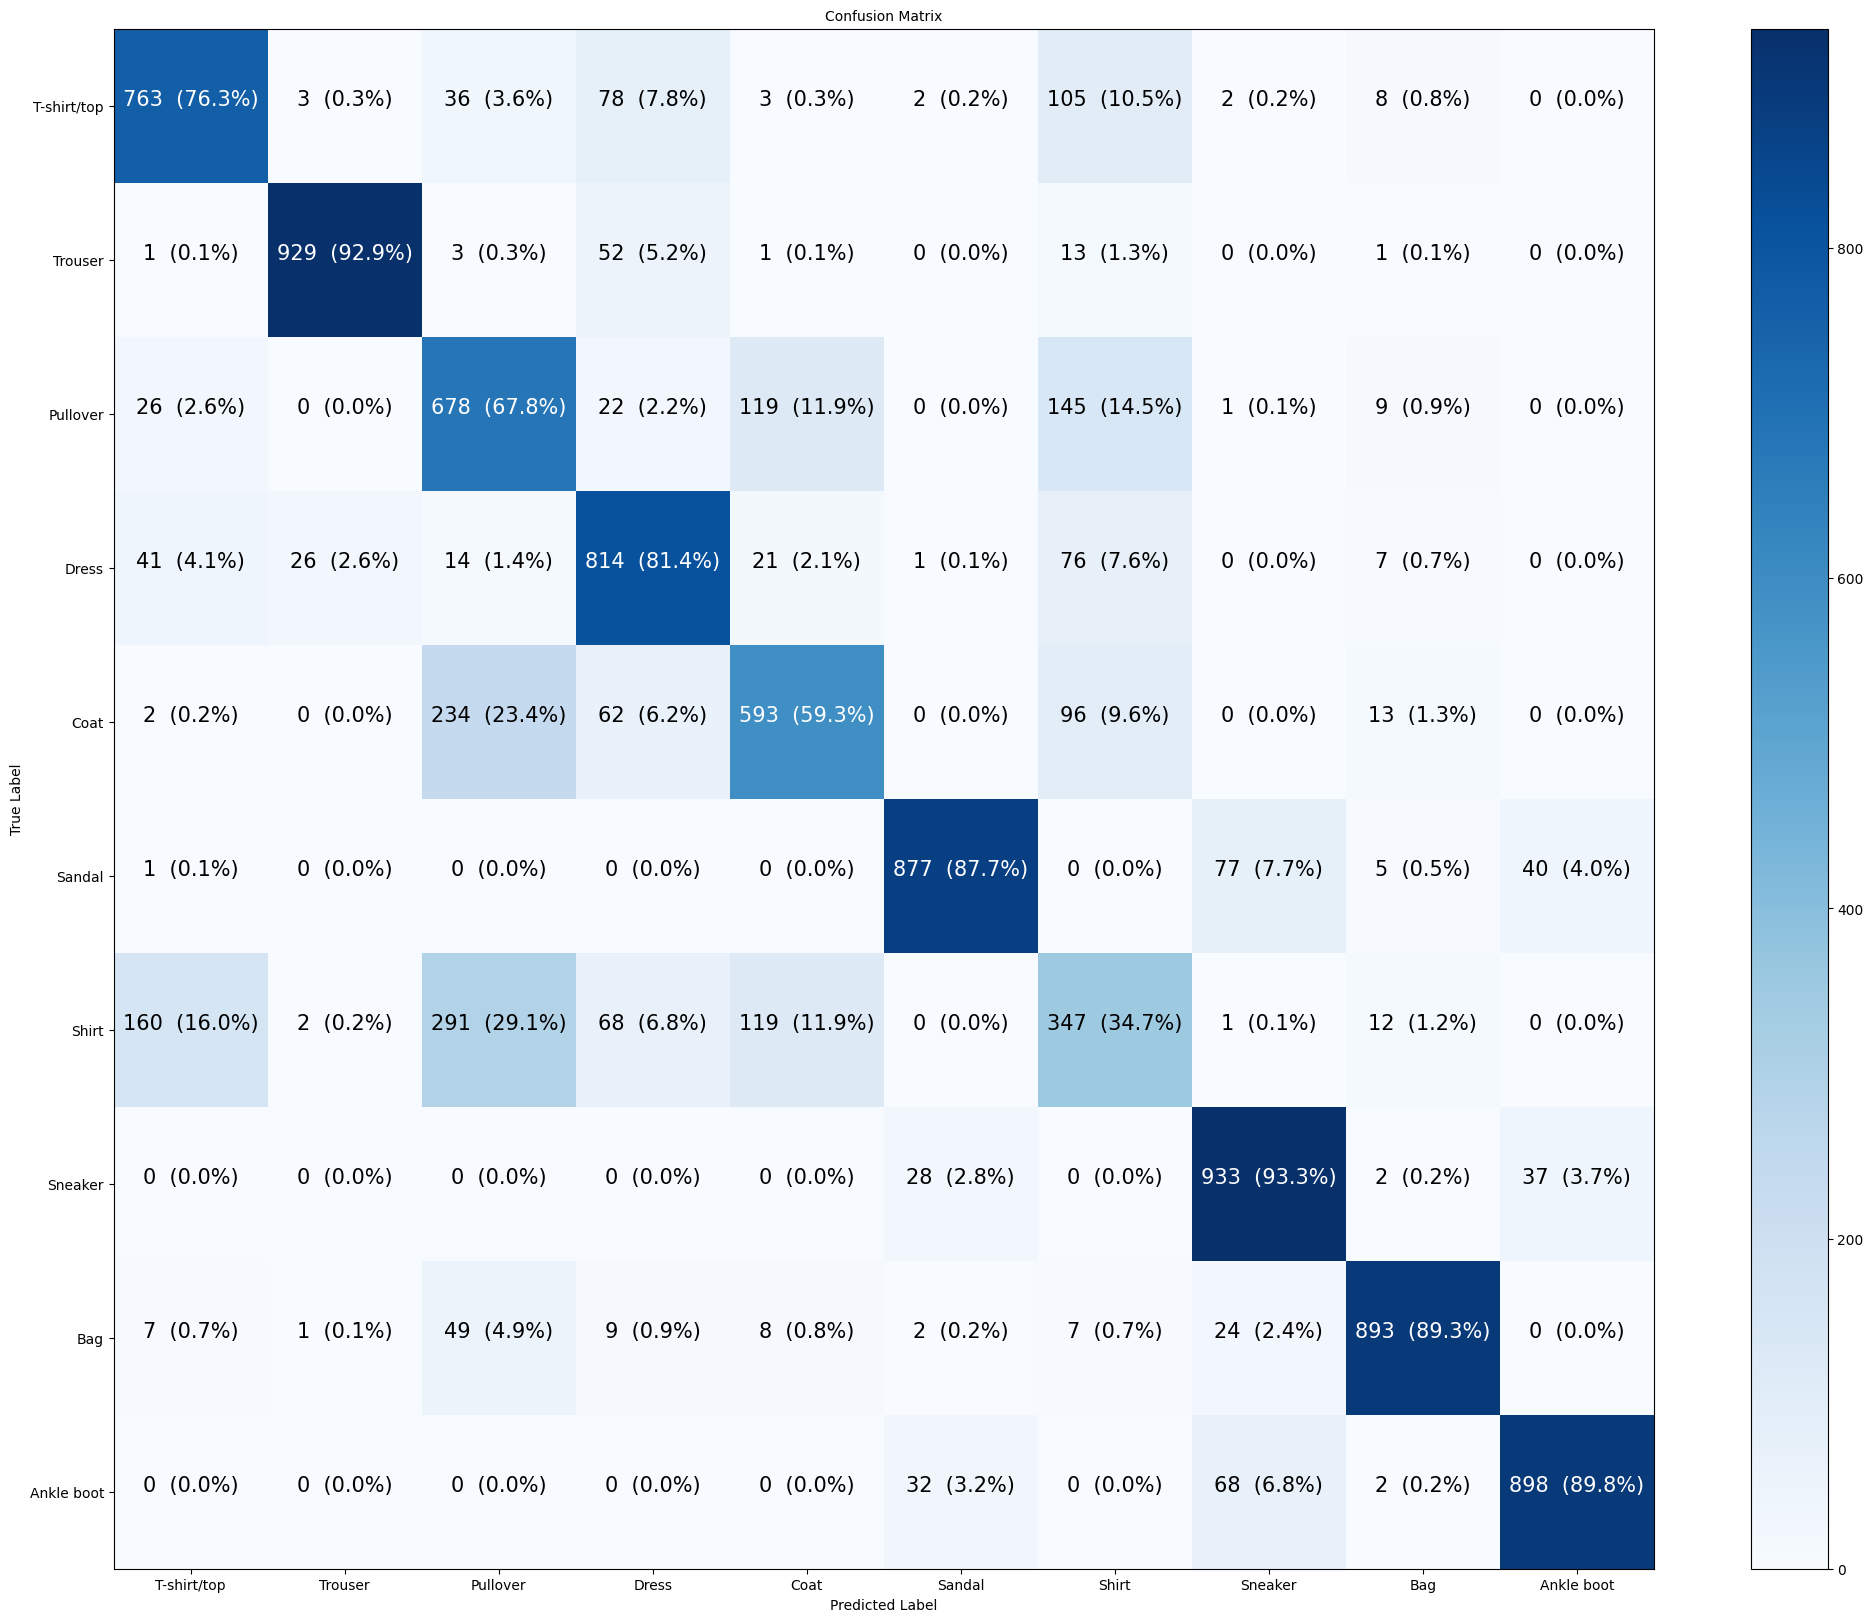

In [49]:
# make a prttier confusion matrix
make_confusion_matrix(y_true=test_labels,
                      y_pred=y_preds,
                      classes=class_names,
                      figsize=(25, 20),
                      text_size=10)

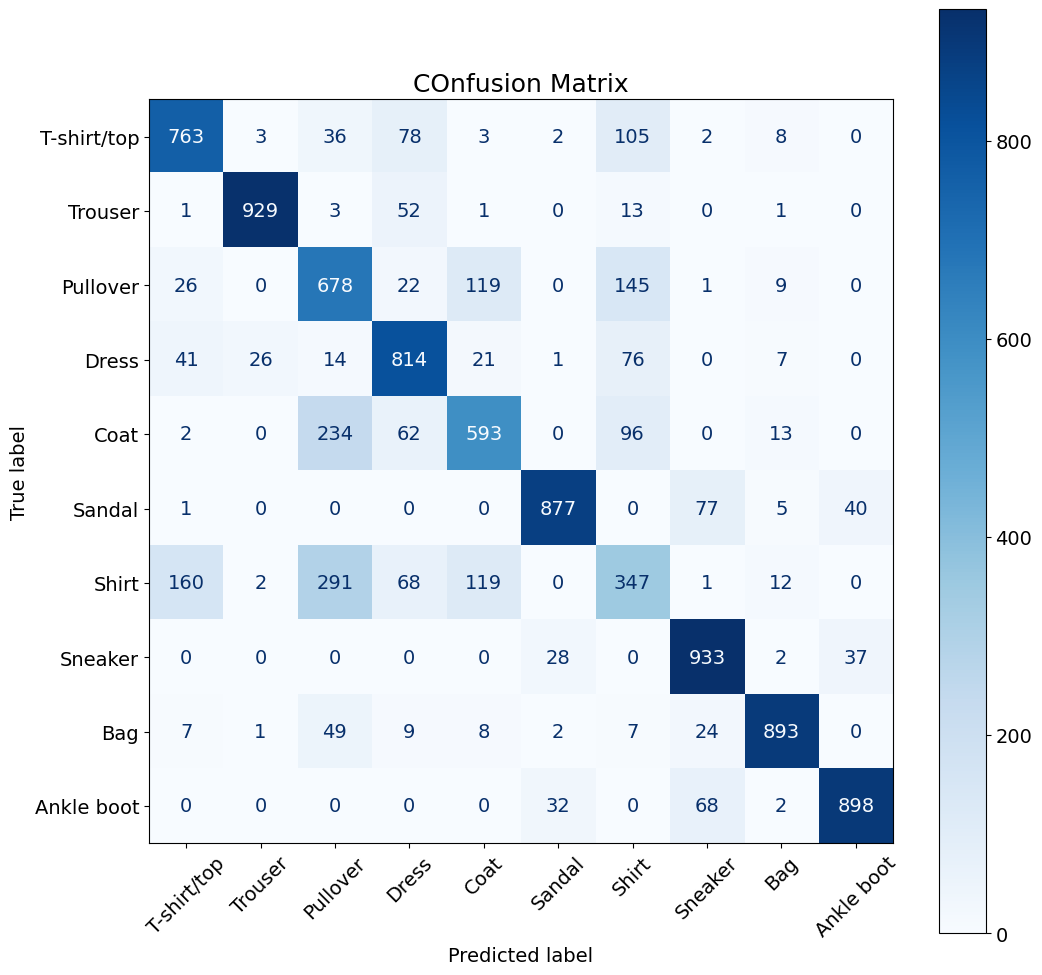

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true=test_labels,
                      y_pred=y_preds)


plt.rcParams.update({'font.size':14})
fig, ax = plt.subplots(figsize=(12, 12))
display = ConfusionMatrixDisplay(cm, 
                       display_labels=class_names)

display.plot(ax=ax,
             cmap='Blues', 
             xticks_rotation=45)
plt.title('COnfusion Matrix', fontsize=18)
plt.show()

🔑 **Note**: Often when working with images and other forms of visual data, it's good to visualise as much as possible to develop a further understanding of the data and the inputs and outputs of the model.

How about we create a fun litte function for:
* Plot a random image
* Make a prediction on said image
* Label the plot with the truth label and the prediction label

In [85]:
# plot a random image
import random

def plot_random_image(model, images, true_labels, classes):
    '''
    Picks a random image, plot it and label it with a prediction and truth label.
    ''' 
    
    # set up a random integer
    i = random.randint(0, len(images))
    
    # create prediction and images
    target_image = images[i]
    pred_probs = model.predict(target_image.reshape(1, 28, 28))
    pred_label = classes[pred_probs.argmax()]
    true_label = classes[true_labels[i]]
    
    # plot the image
    plt.imshow(target_image, cmap=plt.cm.binary)
    
    # change the plotcolor of the titles depending on if the prediction is roght or wrong
    if pred_label == true_label:
        color = 'green'
    else:
        color = 'red'
        
    # add xlabel information (prediction/true label)
    plt.xlabel("Pred: {} {:2.0f}& (True: {})".format(pred_label,
                                                     100*tf.reduce_max(pred_probs),
                                                     true_label), 
               color=color) # set the color based on prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


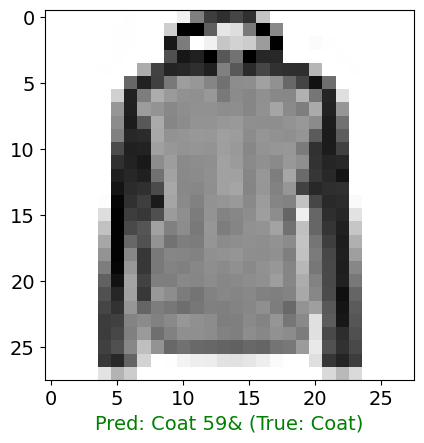

In [95]:
# check out the random image and its prediction
plot_random_image(model=model_2,
                  images=test_data_norm,
                  true_labels=test_labels,
                  classes=class_names)

### What `patterns` is our model learning???

In [97]:
# Find the layers of our model recent layers
model_2.layers

[<Flatten name=flatten_6, built=True>,
 <Dense name=dense_12, built=True>,
 <Dense name=dense_13, built=True>,
 <Dense name=dense_14, built=True>]

In [98]:
# Extract a particular layer
model_2.layers[1]

<Dense name=dense_12, built=True>

In [100]:
# Get the patterns of a layer in our network
weights, biases  = model.layers[1].get_weights()

# Shapes
weights, weights.shape

(array([[ 0.01958267, -0.03800929, -0.01731053,  0.01300284],
        [ 0.00315122, -0.02559001, -0.02909108, -0.04577877],
        [-0.02539528,  0.05298431, -0.05715255, -0.01559368],
        ...,
        [ 0.02786271, -0.03037316, -0.04421755, -0.00527761],
        [ 0.08594966,  0.02377446,  0.06712313,  0.05128989],
        [-0.00337599,  0.02245449, -0.06773966,  0.07727127]],
       dtype=float32),
 (784, 4))

In [102]:
model_2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

Now let's check out the bias vector

In [103]:
# Bias and bias shapes
biases, biases.shape

(array([-0.02292281, -0.01409702, -0.01774839, -0.01644855], dtype=float32),
 (4,))

Every neuron has a bias vector, Each of these is paired with a weights matrix.

The Bias vector get initialized as zeros (at least in the case of a TensorFLow Dense layers).

The bias vector dictates how much the patterns within the corresponding weights matrix should influence the next layer.

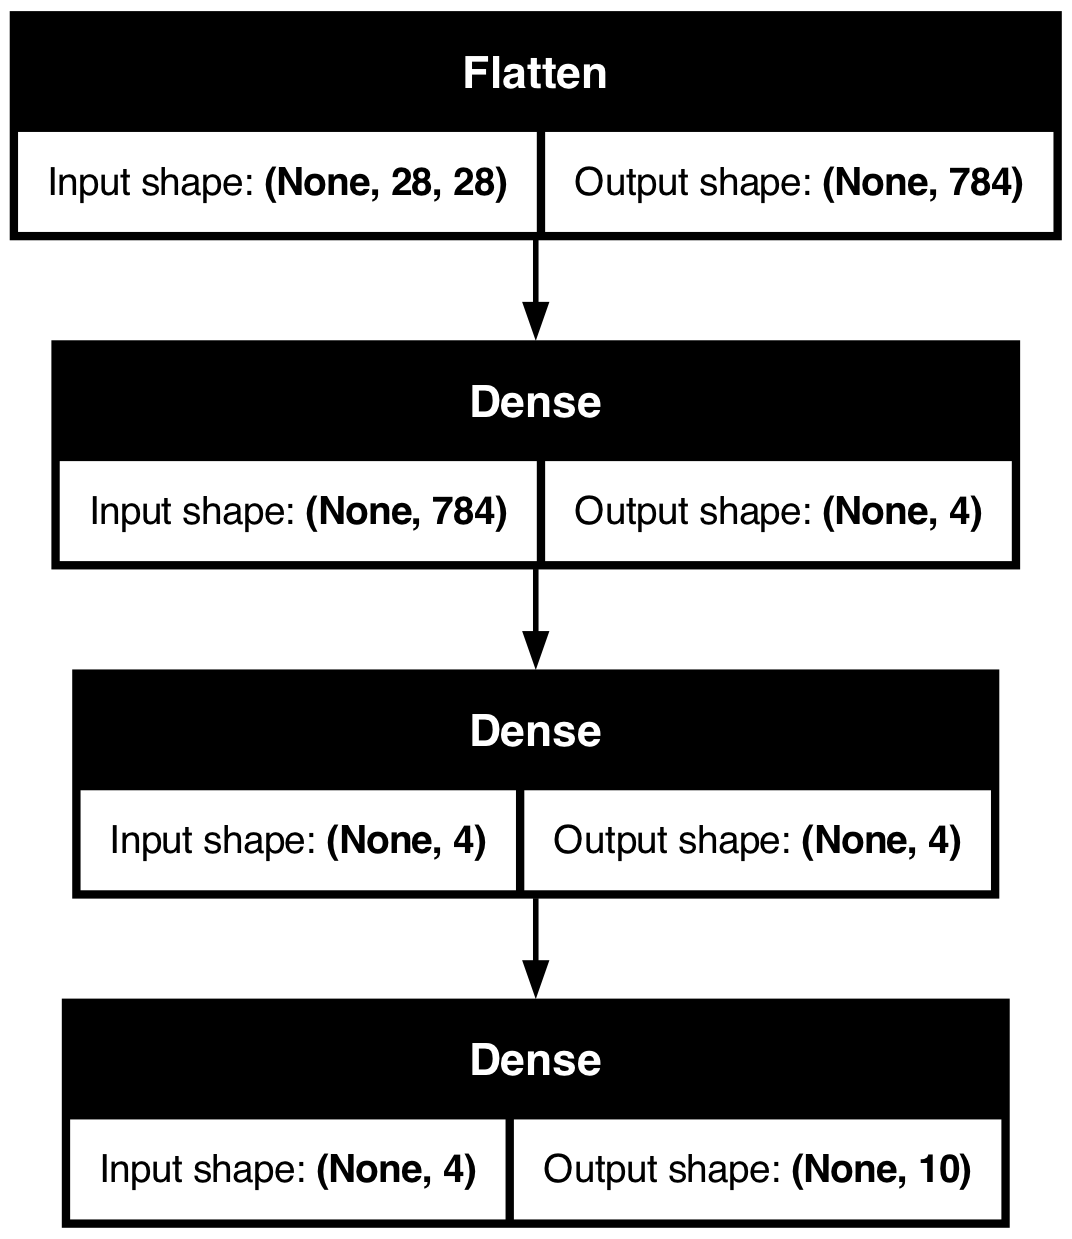

In [104]:
# let's check out another way of viewing our deep learning modeks
from tensorflow.keras.utils import plot_model

# see tge inputs and outputs of each layer
plot_model(model_2, show_shapes=True)

`plt.imshow()` test

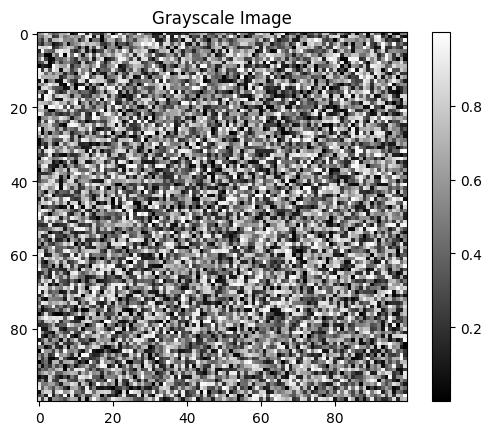

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2D array (grayscale image)
img = np.random.rand(100, 100)

plt.imshow(img, cmap='gray')
plt.colorbar()  # Show color scale
plt.title("Grayscale Image")
plt.show()

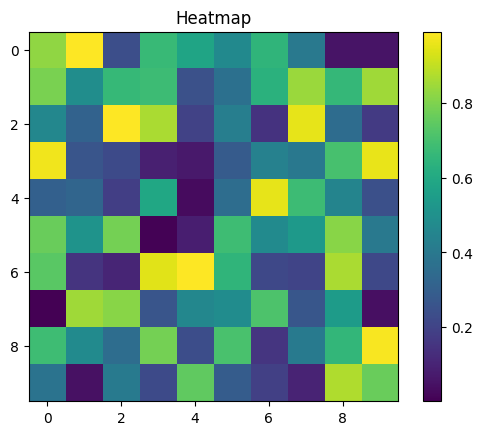

In [ ]:
data = np.random.rand(10, 10)

plt.imshow(data, cmap='viridis')
plt.colorbar()
plt.title("Heatmap")
plt.show()